In [31]:
import numpy as np
import pandas as pd
import pandas_datareader.data as web
import scipy.stats as stats
from arch import arch_model
import matplotlib.pyplot as plt
import seaborn as sns

In [32]:
X = 'DGS10'
Y = 'AAA10Y'

tsy_tickers = [X, Y]
tsy_data = web.DataReader(tsy_tickers, 'fred', start='2000-01-01').dropna()

In [33]:
tsy_changes = tsy_data.diff().dropna()
(tsy_changes == 0).mean()

DGS10     0.077888
AAA10Y    0.180566
dtype: float64

In [34]:
tsy_changes

,DGS10,AAA10Y
DATE,,
2000-01-04,-0.09,0.03
2000-01-05,0.13,-0.04
2000-01-06,-0.05,-0.01
2000-01-07,-0.05,0.02
2000-01-10,0.05,-0.02
...,...,...
2026-02-23,-0.05,0.03
2026-02-24,0.01,0.00
2026-02-25,0.01,-0.01


В данных от FRED видим значения с точностью до 2 знаков после запятой. Из-за этого в данных ежедневных изменений возникает много нулей (7.8% у DGS10 и 18.1% у AAA10Y), которые потом пагубно влияют на анализ с помощью копул, так как мы моделируем наши величины непрерывными распределениями Стьюдента, а нули создают точечную массу в маргинальных распределениях, что нарушает предположение непрерывности.

Из потенциальных вариантов решения проблемы были рассмотрены следующие:

- Найти другой источник информации. К сожалению этот способ оказался нереализуем, так как бесплатные источники данных очень ограничены, а использование других переменных (например, доходности Bonds ETF) приведет к потере такой репрезентативной оценки кредитного риска, как спреды облигаций высокого рейтинга. 

- Отсэмплировать данные с меньшей частотой, например, еженедельной или ежемесячной, а не ежедневной. К сожалению, этот способ приведет к огромному сжатию и потере большого количества данных, хоть и существенно сократит количество нулей. Конкретнее: с 6535 дневных наблюдений еженедельно получается ~1300, ежемесячно — ~300. Еще один важный аргумент: при ресэмплировании теряется информация о краткосрочной динамике, особенно в кризисные периоды

- Добавить в данных небольшой искусственный шум, моделирующий погрешность измерений от FRED. Этот способ оказался наиболее подходящим с моей точки зрения. Его главный недостаток является в том, что мы вносим независимый шум в пару распределений, взаимосвязь которых мы хотим измерить. Это конечно повлияет на корреляцию, но если сделать это аккуратно (например, в виде равномерного распределения от -0.005 до 0.005), то это повлияет на анализ лишь незначительно.

Таким образом мною реализован последний вариант

In [35]:
tsy_data += np.random.uniform(-0.005, 0.005, size=tsy_data.shape)
tsy_changes = tsy_data.diff().dropna()
(tsy_changes == 0).mean()

DGS10     0.0
AAA10Y    0.0
dtype: float64

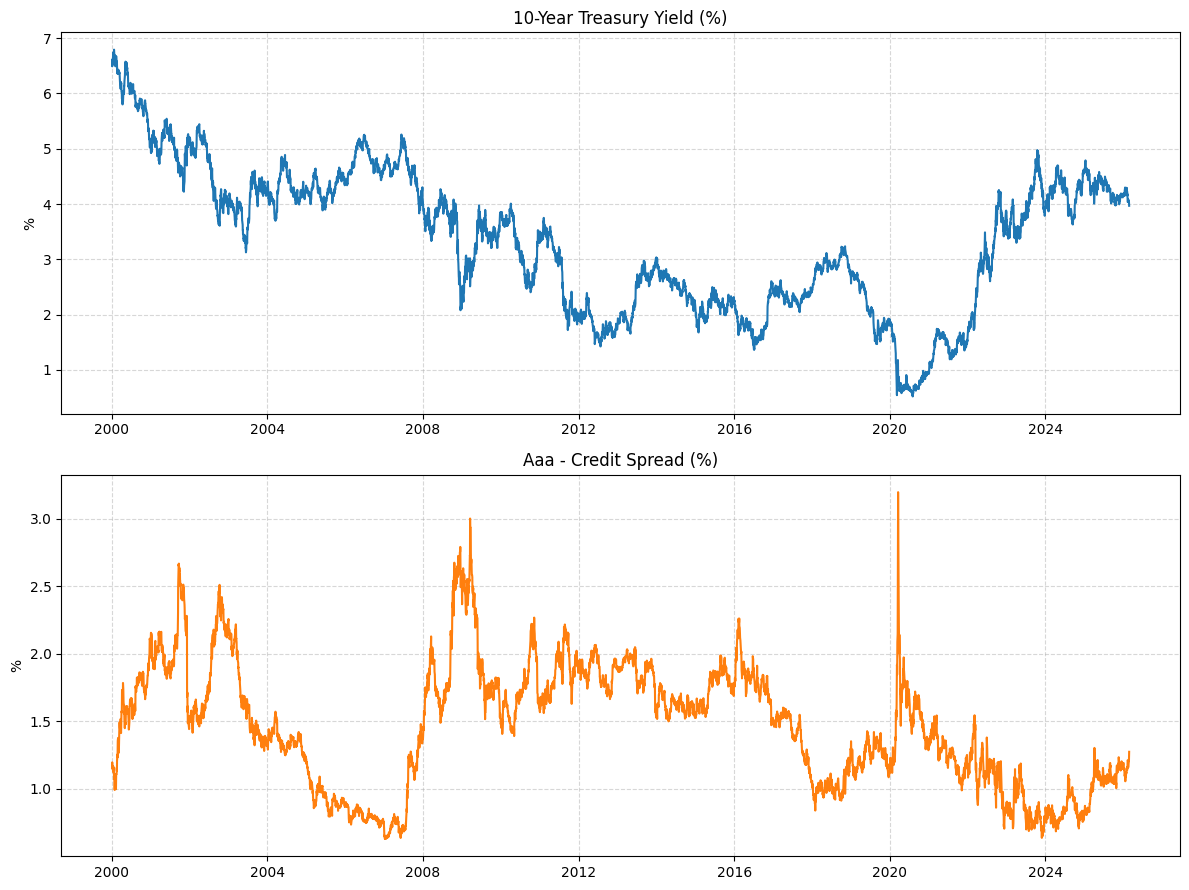

In [36]:
fig, axes = plt.subplots(2, 1, figsize=(12, 9))
variables = [X, Y]
titles = ['10-Year Treasury Yield (%)', 'Aaa - Credit Spread (%)']
colors = ['tab:blue', 'tab:orange']

for i, var in enumerate(variables):
    axes[i].plot(tsy_data.index, tsy_data[var], color=colors[i])
    axes[i].set_title(titles[i])
    axes[i].grid(True, linestyle='--', alpha=0.5)
    axes[i].set_ylabel('%')
plt.tight_layout()
plt.show()

In [37]:
tsy_changes

,DGS10,AAA10Y
DATE,,
2000-01-04,-0.088397,0.022032
2000-01-05,0.126105,-0.031917
2000-01-06,-0.050933,-0.017231
2000-01-07,-0.046114,0.019380
2000-01-10,0.052879,-0.012733
...,...,...
2026-02-23,-0.041657,0.027149
2026-02-24,0.009723,-0.003224
2026-02-25,0.004931,-0.000897


In [38]:
results_dict = {}
std_resids = {}

for var in [X, Y]:
    y = tsy_changes[var].dropna()
    
    model = arch_model(y, mean='Zero', vol='GARCH', p=1, q=1, dist='t', rescale=False)
    res = model.fit(disp='off')
    
    results_dict[var] = res
    std_resids[var] = res.resid / res.conditional_volatility

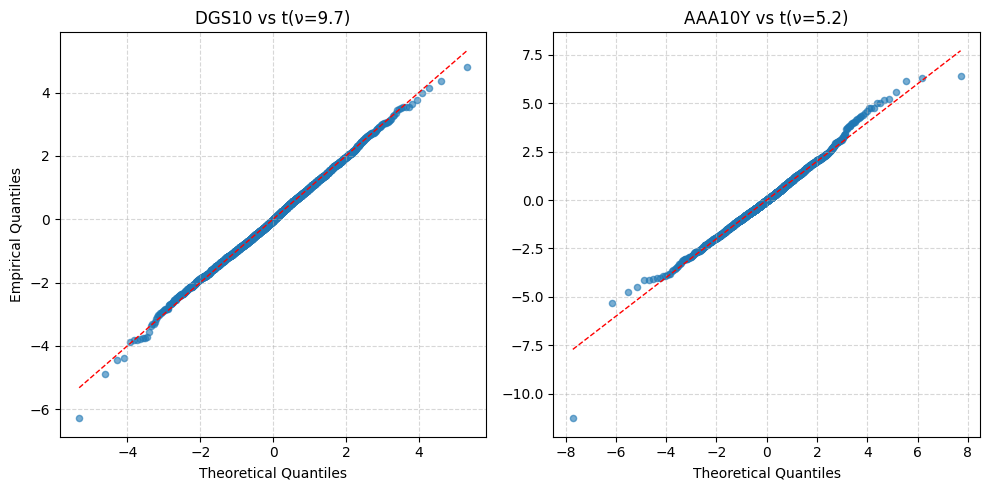

In [39]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5), sharex='col', sharey='col')

for j, var in enumerate([X, Y]):
    ax = axes[j]
    std_resid = std_resids[var]
    res = results_dict[var]
    
    # Sort empirical residuals
    empirical = np.sort(std_resid)
    n = len(empirical)
    probs = (np.arange(1, n + 1) - 0.5) / n

    nu = res.params['nu']
    scale = np.sqrt((nu - 2)/nu)
    theoretical = stats.t.ppf(probs, df=nu) * scale
    title = f'{var} vs t(ν={nu:.1f})'

    # Plot
    ax.scatter(theoretical, empirical, alpha=0.6, s=20)
    ax.plot(
        [theoretical.min(), theoretical.max()],
        [theoretical.min(), theoretical.max()],
        color='red', linestyle='--', linewidth=1
    )
    ax.set_title(title)
    ax.grid(True, linestyle='--', alpha=0.5)
    if j == 0:
        ax.set_ylabel('Empirical Quantiles')
    ax.set_xlabel('Theoretical Quantiles')

plt.tight_layout()
plt.show()

# 1. Трансформация Standardized Residuals от GARCH модели в равномерное распределение U[0,1]

In [40]:
import numpy as np
import pandas as pd
import scipy.stats as stats
from scipy.optimize import minimize
import matplotlib.pyplot as plt

resid_1 = std_resids[X].values
resid_2 = std_resids[Y].values

# Get the degrees of freedom (nu) estimated from the marginal GARCH-t models
nu_1 = results_dict[X].params['nu']
nu_2 = results_dict[Y].params['nu']

# Probability Integral Transform (PIT)
u1 = stats.t.cdf(resid_1, df=nu_1)
u2 = stats.t.cdf(resid_2, df=nu_2)

T = len(u1)
T

6535

In [41]:
np.isnan(u1).sum(), np.isnan(u2).sum(), np.isinf(u1).sum(), np.isinf(u2).sum() 

(np.int64(0), np.int64(0), np.int64(0), np.int64(0))

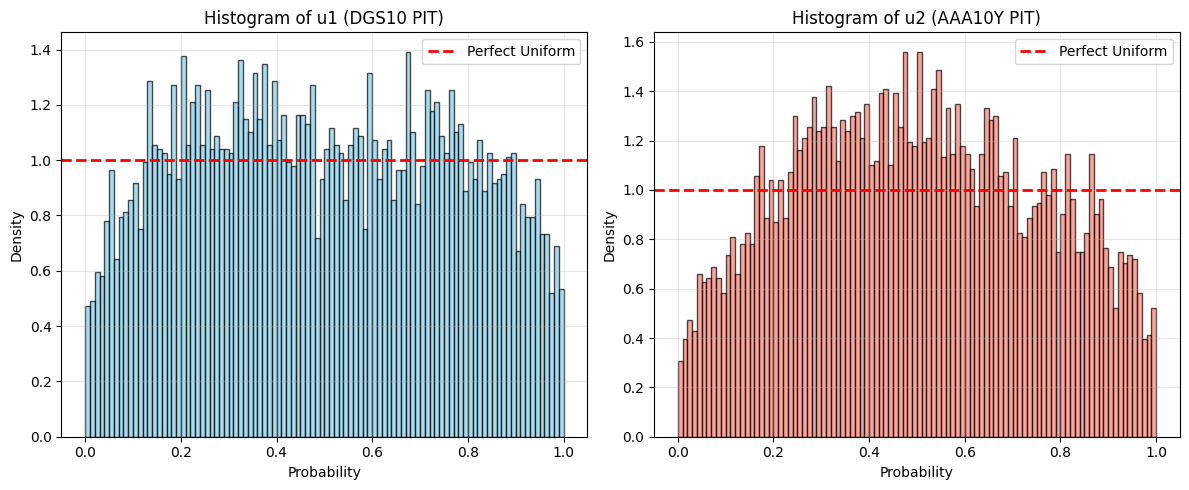

In [42]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Histogram for u1 (DGS10)
axes[0].hist(u1, bins=100, range=(0, 1), density=True, alpha=0.7, color='skyblue', edgecolor='black')
axes[0].axhline(1, color='red', linestyle='--', linewidth=2, label='Perfect Uniform')
axes[0].set_title('Histogram of u1 (DGS10 PIT)')
axes[0].set_xlabel('Probability')
axes[0].set_ylabel('Density')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Histogram for u2 (AAA10Y)
axes[1].hist(u2, bins=100, range=(0, 1), density=True, alpha=0.7, color='salmon', edgecolor='black')
axes[1].axhline(1, color='red', linestyle='--', linewidth=2, label='Perfect Uniform')
axes[1].set_title('Histogram of u2 (AAA10Y PIT)')
axes[1].set_xlabel('Probability')
axes[1].set_ylabel('Density')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 2. Гауссова копула с переменными во времени параметрами

Следуя Ji et al. (2018) и статье о переходах экстремального риска, реализована динамическая гауссова копула, в которой коэффициент корреляции $\rho_t$ подчиняется процессу ARMA(1,m):

$$\rho_t = \Lambda\!\left(\omega + \beta \cdot \rho_{t-1} + \alpha \cdot \frac{1}{m}\sum_{j=1}^{m} \Phi^{-1}(u_{1,t-j})\cdot\Phi^{-1}(u_{2,t-j})\right)$$

где $\Lambda(x) = \tanh(x/2) = \frac{1-e^{-x}}{1+e^{-x}}$ — функция, сохраняющая $\rho_t \in (-1,1)$, а оцениваемыми параметрами являются $\theta_c = (\omega, \beta, \alpha)$.

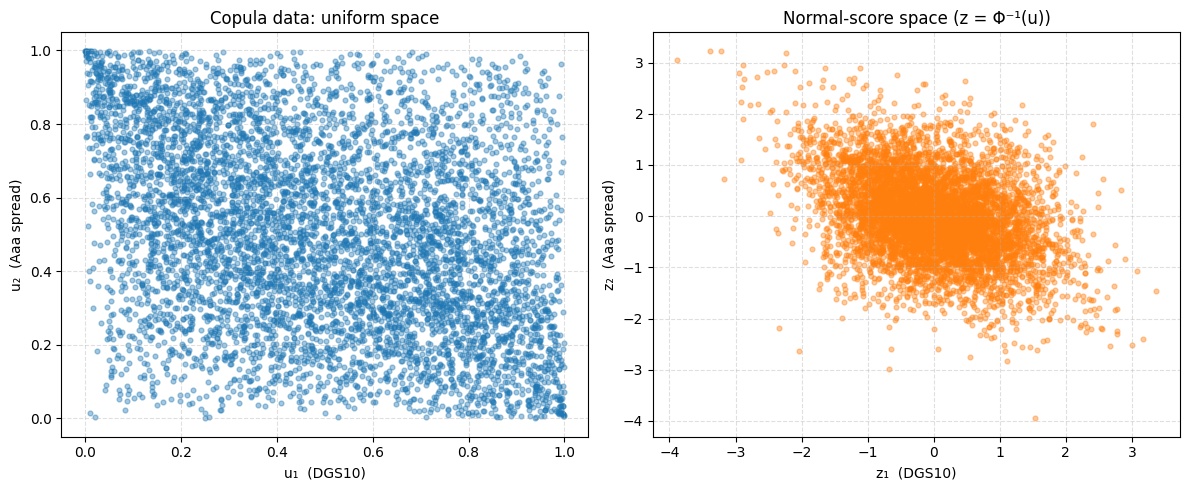

Sample Pearson correlation of z-scores: -0.3738


In [43]:
# Clip slightly away from 0/1 to avoid ±inf in ppf
u1c = np.clip(u1, 1e-6, 1 - 1e-6)
u2c = np.clip(u2, 1e-6, 1 - 1e-6)

z1 = stats.norm.ppf(u1c)   # Φ⁻¹(u1)
z2 = stats.norm.ppf(u2c)   # Φ⁻¹(u2)

# Quick look at the copula scatter (uniform space vs normal-score space)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(u1, u2, alpha=0.4, s=12)
axes[0].set_title('Copula data: uniform space')
axes[0].set_xlabel('u₁  (DGS10)')
axes[0].set_ylabel('u₂  (Aaa spread)')
axes[0].grid(True, linestyle='--', alpha=0.4)

axes[1].scatter(z1, z2, alpha=0.4, s=12, color='tab:orange')
axes[1].set_title('Normal-score space (z = Φ⁻¹(u))')
axes[1].set_xlabel('z₁  (DGS10)')
axes[1].set_ylabel('z₂  (Aaa spread)')
axes[1].grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

print(f"Sample Pearson correlation of z-scores: {np.corrcoef(z1, z2)[0,1]:.4f}")

## 2.1 Динамическая копула ARMA(1, m)

In [44]:
# ==============================================================================
# Model definition: ARMA(1,m) time-varying Gaussian copula
# ==============================================================================

def logistic(x):
    """Λ(x) = tanh(x/2): bijection ℝ → (-1, 1)."""
    return np.tanh(x / 2.0)


def compute_rho_path(omega, beta, alpha, z1, z2, m=10):
    """
    Compute the sequence of dynamic correlations ρ_t via:
        ρ_t = Λ(ω + β·ρ_{t-1} + α · (1/m) · Σ_{j=1}^{m} z1_{t-j}·z2_{t-j})

    Initialised at the full-sample Pearson correlation.
    For t < m only the available lagged cross-products are averaged.
    """
    T = len(z1)
    rho = np.empty(T)
    cross = z1 * z2  # element-wise cross products

    rho_prev = np.corrcoef(z1, z2)[0, 1]  # initialisation

    for t in range(T):
        # Lagged cross-product mean: indices t-m … t-1
        if t == 0:
            avg_cross = 0.0          # no past data
        elif t < m:
            avg_cross = cross[:t].mean()
        else:
            avg_cross = cross[t - m:t].mean()

        x = omega + beta * rho_prev + alpha * avg_cross
        rho[t] = logistic(x)
        rho_prev = rho[t]

    return rho


def gaussian_copula_nll(params, z1, z2, m=10):
    """
    Negative log-likelihood of the time-varying Gaussian copula.

    Copula log-density at each t:
        log c(u1,u2;ρ) = -½log(1-ρ²)
                         - ρ²(z1²+z2²) / [2(1-ρ²)]
                         + ρ·z1·z2 / (1-ρ²)
    """
    omega, beta, alpha = params

    rho = compute_rho_path(omega, beta, alpha, z1, z2, m)
    rho = np.clip(rho, -0.9999, 0.9999)

    r2 = rho ** 2
    log_c = (
        -0.5 * np.log1p(-r2)
        - r2 * (z1 ** 2 + z2 ** 2) / (2.0 * (1.0 - r2))
        + rho * z1 * z2 / (1.0 - r2)
    )

    return -np.sum(log_c)

## 2.2 Оптимальное значение параметра m

In [ ]:
from scipy.optimize import minimize

bounds = [(-5, 5), (-0.9999, 0.9999), (-5, 5)]

starting_points = [
    [ 0.0,  0.95,  0.10],
    [ 0.1,  0.85,  0.05],
    [-0.1,  0.90, -0.05],
    [ 0.0,  0.50,  0.20],
    [ 0.0,  0.70,  0.30],
]

M_values = list(range(10, 160, 10)) 

m_results = []

for m in M_values:
    best = None
    for x0 in starting_points:
        res = minimize(
            gaussian_copula_nll,
            x0,
            args=(z1, z2, m),
            method='L-BFGS-B',
            bounds=bounds,
            options={'maxiter': 2000, 'ftol': 1e-14, 'gtol': 1e-8},
        )
        if best is None or res.fun < best.fun:
            best = res

    m_results.append({
        'M':          m,
        'loglik':    -best.fun,
        'omega':      best.x[0],
        'beta':       best.x[1],
        'alpha':      best.x[2],
        'converged':  best.success,
    })
    print(f"  M={m:2d}  log-lik={-best.fun:10.4f}  converged={best.success}")

df_m = pd.DataFrame(m_results).set_index('M')

best_M  = df_m['loglik'].idxmax()
best_ll = df_m['loglik'].max()

print("\n" + "=" * 55)
print("  M Selection Summary")
print("=" * 55)
print(df_m[['loglik', 'omega', 'beta', 'alpha', 'converged']].to_string())
print("=" * 55)
print(f"  Best M = {best_M}  (log-likelihood = {best_ll:.4f})")

  M=10  log-lik=  594.3250  converged=True
  M=20  log-lik=  611.5641  converged=True
  M=30  log-lik=  627.4641  converged=True
  M=40  log-lik=  628.6858  converged=True
  M=50  log-lik=  635.2183  converged=True
  M=60  log-lik=  639.6359  converged=True
  M=70  log-lik=  647.5789  converged=True
  M=80  log-lik=  658.2943  converged=True
  M=90  log-lik=  657.6607  converged=True
  M=100  log-lik=  650.8907  converged=True
  M=110  log-lik=  649.1996  converged=True
  M=120  log-lik=  648.5842  converged=True
  M=130  log-lik=  642.5608  converged=True
  M=140  log-lik=  639.5590  converged=True
  M=150  log-lik=  636.3065  converged=True

  M Selection Summary
         loglik     omega      beta     alpha  converged
M                                                       
10   594.325026 -0.421431  0.999900  0.538511       True
20   611.564145 -0.368880  0.999900  0.742968       True
30   627.464110 -0.315758  0.999900  0.945362       True
40   628.685763 -0.282940  0.999900  1.05

In [ ]:
M = best_M  # ARMA lag window (m in the paper)

best_result = None
for x0 in starting_points:
    res = minimize(
        gaussian_copula_nll,
        x0,
        args=(z1, z2, M),
        method='L-BFGS-B',
        bounds=bounds,
        options={'maxiter': 2000, 'ftol': 1e-14, 'gtol': 1e-8},
    )
    if best_result is None or res.fun < best_result.fun:
        best_result = res

omega_hat, beta_hat, alpha_hat = best_result.x
loglik_hat = -best_result.fun

print("=" * 50)
print("  Time-Varying Gaussian Copula — Estimates")
print("=" * 50)
print(f"  ω  (intercept)  = {omega_hat: .6f}")
print(f"  β  (persistence)= {beta_hat: .6f}")
print(f"  α  (innovation) = {alpha_hat: .6f}")
print(f"  m  (lag window) = {M}")
print(f"  Log-likelihood  = {loglik_hat:.4f}")
print(f"  Converged:        {best_result.success}")

  Time-Varying Gaussian Copula — Estimates
  ω  (intercept)  = -0.668578
  β  (persistence)= -0.999900
  α  (innovation) =  3.024093
  m  (lag window) = 80
  Log-likelihood  = 651.8158
  Converged:        True


## 2.3 Итоговый график изменяющейся копулы

Даты кризисов подобраны в соответствии с National Bureau of Economic Research https://fredhelp.stlouisfed.org/fred/data/understanding-the-data/recession-bars/

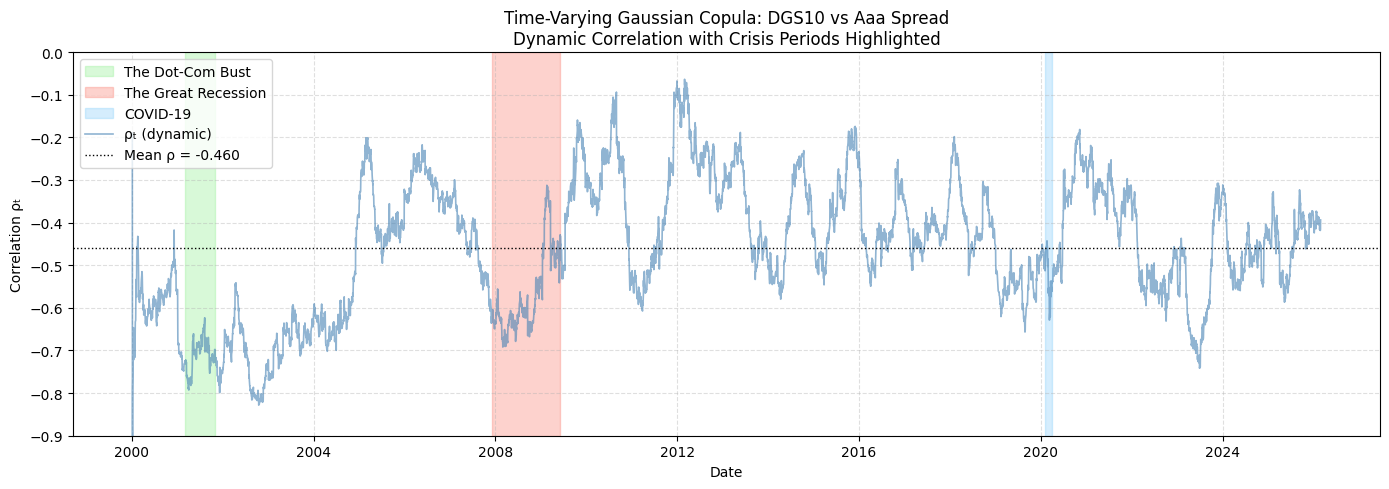

The Dot-Com Bust                mean ρ = -0.7105  min ρ = -0.7929  max ρ = -0.6233
The Great Recession             mean ρ = -0.5704  min ρ = -0.6920  max ρ = -0.3125
COVID-19                        mean ρ = -0.5304  min ρ = -0.6287  max ρ = -0.4428


In [ ]:
rho_path = compute_rho_path(omega_hat, beta_hat, alpha_hat, z1, z2, M)
dates = tsy_data.index[1:]

rho_series = pd.Series(rho_path, index=dates)
rho_ema = rho_series.ewm(span=63, adjust=False).mean()  # ~1-quarter EMA

fig, ax = plt.subplots(figsize=(14, 5))

# Crisis / event windows
crises = [
    ('2001-03-01', '2001-11-01', 'lightgreen', 'The Dot-Com Bust'),
    ('2007-12-01', '2009-06-01', 'salmon', 'The Great Recession'),
    ('2020-02-01', '2020-04-01', 'lightskyblue', 'COVID-19'),
]

for start, end, color, label in crises:
    ax.axvspan(pd.Timestamp(start), pd.Timestamp(end),
               color=color, alpha=0.35, label=label)

ax.plot(dates, rho_path, color='steelblue', linewidth=1.2, label='ρₜ (dynamic)', alpha=0.6)

ax.axhline(rho_series.mean(), color='black', linestyle=':', linewidth=1,
           label=f'Mean ρ = {rho_series.mean():.3f}')
ax.axhline(0, color='black', linewidth=0.5)

ax.set_ylabel('Correlation ρₜ')
ax.set_xlabel('Date')
ax.set_title('Time-Varying Gaussian Copula: DGS10 vs Aaa Spread\n'
             'Dynamic Correlation with Crisis Periods Highlighted')
ax.set_ylim(-0.9, -0.0)
ax.legend(loc='upper left')
ax.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

# Print average ρ inside each crisis window
for start, end, _, label in crises:
    window = rho_series[start:end]
    print(f"{label:30s}  mean ρ = {window.mean():.4f}  "
          f"min ρ = {window.min():.4f}  max ρ = {window.max():.4f}")

# 3. t-Копула с переменными во времени параметрами

Как и в случае гауссовой копулы, временная корреляция задаётся процессом ARMA(1,m), однако перекрёстные произведения вычисляются с использованием обратной функции распределения Стьюдента $t_\nu^{-1}$, а степени свободы $\nu$ становятся четвёртым параметром, оцениваемым совместно с остальными:

$$\rho_t = \Lambda\!\left(\omega + \beta \cdot \rho_{t-1} + \alpha \cdot \frac{1}{m}\sum_{j=1}^{m} t_\nu^{-1}(u_{1,t-j})\cdot t_\nu^{-1}(u_{2,t-j})\right), \quad \theta_c = (\omega, \beta, \alpha, \nu)^\prime$$

Preliminary ν (avg of GARCH-t marginals): 7.44
Note: ν will be re-estimated jointly with (ω, β, α) in the copula step.



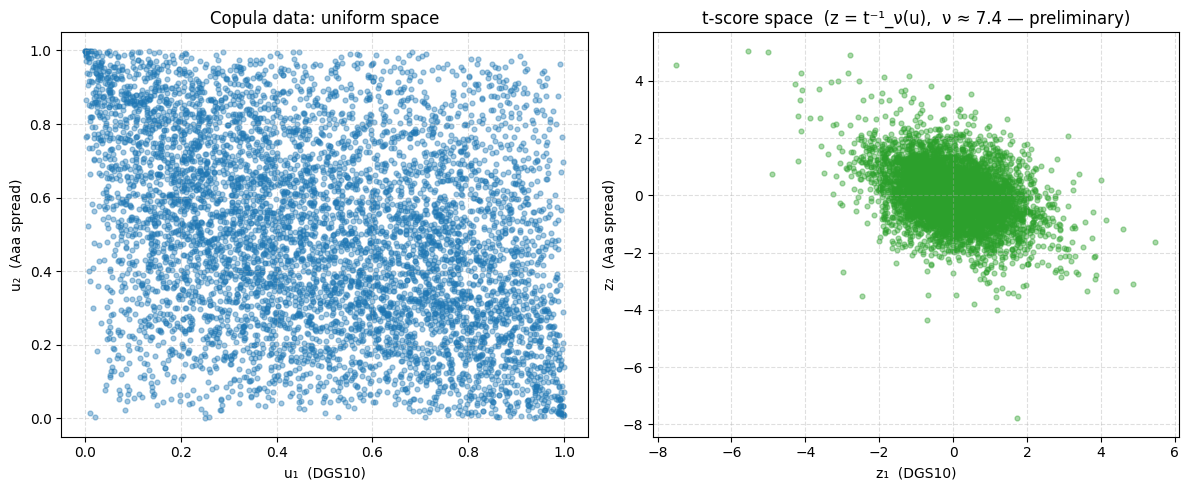

Sample Pearson correlation of t-scores: -0.3856


In [46]:
from scipy import special

nu_preliminary = (nu_1 + nu_2) / 2.0
print(f"Preliminary ν (avg of GARCH-t marginals): {nu_preliminary:.2f}")
print("Note: ν will be re-estimated jointly with (ω, β, α) in the copula step.\n")

# For visualisation only — t-scores at the preliminary ν
zt1_prelim = stats.t.ppf(u1c, df=nu_preliminary)
zt2_prelim = stats.t.ppf(u2c, df=nu_preliminary)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(u1, u2, alpha=0.4, s=12)
axes[0].set_title('Copula data: uniform space')
axes[0].set_xlabel('u₁  (DGS10)')
axes[0].set_ylabel('u₂  (Aaa spread)')
axes[0].grid(True, linestyle='--', alpha=0.4)

axes[1].scatter(zt1_prelim, zt2_prelim, alpha=0.4, s=12, color='tab:green')
axes[1].set_title(f't-score space  (z = t⁻¹_ν(u),  ν ≈ {nu_preliminary:.1f} — preliminary)')
axes[1].set_xlabel('z₁  (DGS10)')
axes[1].set_ylabel('z₂  (Aaa spread)')
axes[1].grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

print(f"Sample Pearson correlation of t-scores: {np.corrcoef(zt1_prelim, zt2_prelim)[0,1]:.4f}")

## 3.1 Динамическая копула ARMA(1, m)

In [ ]:
def compute_rho_path_t(omega, beta, alpha, z1, z2, m=10):
    """
    Same ARMA(1,m) dynamics as the Gaussian copula, but operating on
    t_ν-scores  z_i = t_ν⁻¹(u_i)  instead of Φ⁻¹(u_i).

        ρ_t = Λ(ω + β·ρ_{t-1} + α · (1/m) · Σ_{j=1}^{m} z1_{t-j}·z2_{t-j})

    Initialised at the full-sample Pearson correlation of the t-scores.
    """
    T = len(z1)
    rho = np.empty(T)
    cross = z1 * z2

    rho_prev = np.corrcoef(z1, z2)[0, 1]

    for t in range(T):
        if t == 0:
            avg_cross = 0.0
        elif t < m:
            avg_cross = cross[:t].mean()
        else:
            avg_cross = cross[t - m:t].mean()

        x = omega + beta * rho_prev + alpha * avg_cross
        rho[t] = logistic(x)
        rho_prev = rho[t]

    return rho


def t_copula_nll(params, u1, u2, m=10):
    """
    Negative log-likelihood of the time-varying t-copula.

    params = (omega, beta, alpha, log_nu)   [log_nu = log(ν), keeps ν > 0]

    Copula log-density at each t:
        log c = lgamma((ν+2)/2) + lgamma(ν/2) - 2·lgamma((ν+1)/2)
                - ½ log(1-ρ²)
                - (ν+2)/2 · log(1 + (z1²-2ρ·z1·z2+z2²) / (ν(1-ρ²)))
                + (ν+1)/2 · [log(1+z1²/ν) + log(1+z2²/ν)]
    """
    omega, beta, alpha, log_nu = params
    nu = np.exp(log_nu)   # exp-transform keeps ν > 0 without hard boundary

    # t-scores for this ν (re-evaluated each call since ν is a free parameter)
    z1 = stats.t.ppf(u1, df=nu)
    z2 = stats.t.ppf(u2, df=nu)

    rho = compute_rho_path_t(omega, beta, alpha, z1, z2, m)
    rho = np.clip(rho, -0.9999, 0.9999)

    r2 = rho ** 2
    Q  = z1**2 - 2.0 * rho * z1 * z2 + z2**2   # bivariate-t quadratic form

    log_c = (
        special.gammaln((nu + 2.0) / 2.0)
        + special.gammaln(nu / 2.0)
        - 2.0 * special.gammaln((nu + 1.0) / 2.0)
        - 0.5 * np.log1p(-r2)
        - (nu + 2.0) / 2.0 * np.log1p(Q / (nu * (1.0 - r2)))
        + (nu + 1.0) / 2.0 * (np.log1p(z1**2 / nu) + np.log1p(z2**2 / nu))
    )

    return -np.sum(log_c)

## 3.2 Оптимальное значение параметра m

In [ ]:
from scipy.optimize import minimize

bounds_t = [(-5, 5), (-0.9999, 0.9999), (-5, 5), (np.log(2.1), np.log(50))]

starting_points_t = [
    [ 0.0,  0.95,  0.10, np.log(5)],
    [ 0.1,  0.85,  0.05, np.log(8)],
    [-0.1,  0.90, -0.05, np.log(10)],
    [ 0.0,  0.50,  0.20, np.log(6)],
    [ 0.0,  0.70,  0.30, np.log(4)],
]

M_values_t = list(range(10, 160, 10))

m_results_t = []

for m in M_values_t:
    best = None
    for x0 in starting_points_t:
        res = minimize(
            t_copula_nll,
            x0,
            args=(u1c, u2c, m),
            method='L-BFGS-B',
            bounds=bounds_t,
            options={'maxiter': 2000, 'ftol': 1e-14, 'gtol': 1e-8},
        )
        if best is None or res.fun < best.fun:
            best = res

    nu_est = np.exp(best.x[3])
    m_results_t.append({
        'M':         m,
        'loglik':   -best.fun,
        'omega':     best.x[0],
        'beta':      best.x[1],
        'alpha':     best.x[2],
        'nu':        nu_est,
        'converged': best.success,
    })
    print(f"  M={m:3d}  log-lik={-best.fun:10.4f}  ν={nu_est:6.2f}  converged={best.success}")

df_m_t = pd.DataFrame(m_results_t).set_index('M')

best_M_t  = df_m_t['loglik'].idxmax()
best_ll_t = df_m_t['loglik'].max()

print("\n" + "=" * 65)
print("  M Selection Summary — t-Copula")
print("=" * 65)
print(df_m_t[['loglik', 'omega', 'beta', 'alpha', 'nu', 'converged']].to_string())
print("=" * 65)
print(f"  Best M = {best_M_t}  (log-likelihood = {best_ll_t:.4f})")

  M= 10  log-lik=  657.4652  ν=  5.74  converged=True
  M= 20  log-lik=  676.1305  ν=  6.10  converged=True
  M= 30  log-lik=  684.2300  ν=  6.48  converged=False
  M= 40  log-lik=  688.1504  ν=  6.27  converged=True
  M= 50  log-lik=  690.4368  ν=  6.50  converged=True
  M= 60  log-lik=  697.0415  ν=  6.32  converged=True
  M= 70  log-lik=  703.3923  ν=  6.39  converged=True
  M= 80  log-lik=  712.1041  ν=  6.49  converged=True
  M= 90  log-lik=  710.6281  ν=  6.59  converged=True
  M=100  log-lik=  705.2125  ν=  6.52  converged=True
  M=110  log-lik=  704.5926  ν=  6.46  converged=True
  M=120  log-lik=  704.4879  ν=  6.33  converged=True
  M=130  log-lik=  697.9961  ν=  6.29  converged=True
  M=140  log-lik=  697.0043  ν=  6.14  converged=True
  M=150  log-lik=  693.9059  ν=  6.13  converged=False

  M Selection Summary — t-Copula
         loglik     omega      beta     alpha        nu  converged
M                                                                 
10   657.465155 -0.4

In [48]:
M_t = best_M_t

best_result_t = None
for x0 in starting_points_t:
    res = minimize(
        t_copula_nll,
        x0,
        args=(u1c, u2c, M_t),
        method='L-BFGS-B',
        bounds=bounds_t,
        options={'maxiter': 2000, 'ftol': 1e-14, 'gtol': 1e-8},
    )
    if best_result_t is None or res.fun < best_result_t.fun:
        best_result_t = res

omega_hat_t, beta_hat_t, alpha_hat_t, log_nu_hat = best_result_t.x
nu_hat_t    = np.exp(log_nu_hat)
loglik_hat_t = -best_result_t.fun

print("=" * 50)
print("  Time-Varying t-Copula — Estimates")
print("=" * 50)
print(f"  ω  (intercept)  = {omega_hat_t: .6f}")
print(f"  β  (persistence)= {beta_hat_t: .6f}")
print(f"  α  (innovation) = {alpha_hat_t: .6f}")
print(f"  ν  (tail d.o.f.)= {nu_hat_t: .6f}")
print(f"  m  (lag window) = {M_t}")
print(f"  Log-likelihood  = {loglik_hat_t:.4f}")
print(f"  Converged:        {best_result_t.success}")

  Time-Varying t-Copula — Estimates
  ω  (intercept)  = -0.284205
  β  (persistence)=  0.487261
  α  (innovation) =  1.308748
  ν  (tail d.o.f.)=  6.786371
  m  (lag window) = 80
  Log-likelihood  = 701.5288
  Converged:        True


## 3.3 Итоговый график изменяющейся копулы

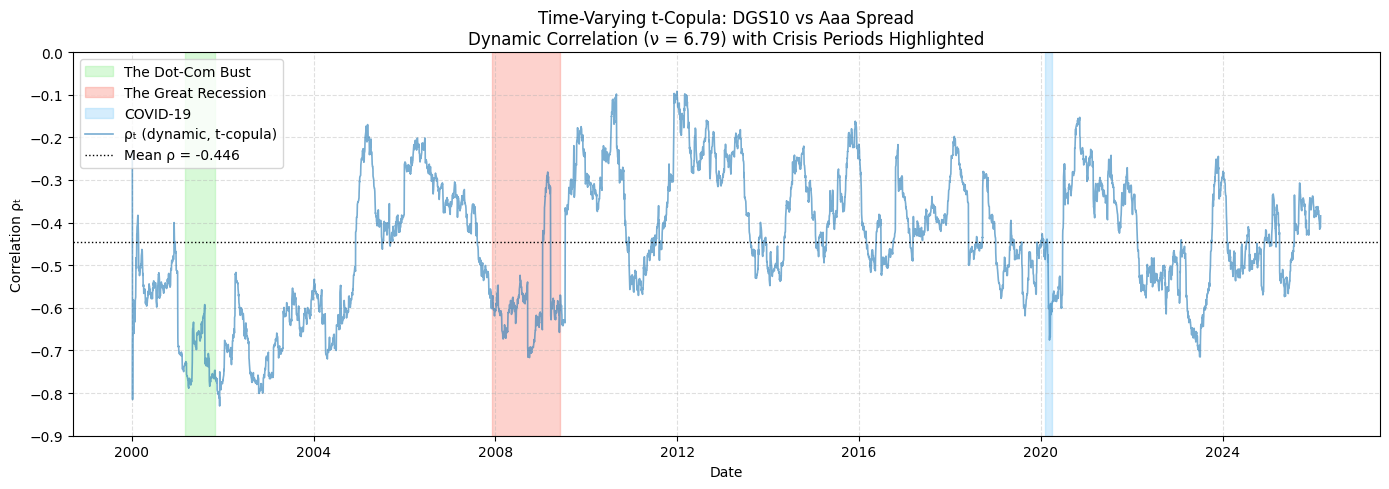

The Dot-Com Bust                mean ρ = -0.7120  min ρ = -0.7886  max ρ = -0.5923
The Great Recession             mean ρ = -0.5835  min ρ = -0.7167  max ρ = -0.2813
COVID-19                        mean ρ = -0.5489  min ρ = -0.6755  max ρ = -0.4386


In [50]:
# Compute t-scores at the estimated ν
zt1_hat = stats.t.ppf(u1c, df=nu_hat_t)
zt2_hat = stats.t.ppf(u2c, df=nu_hat_t)

rho_path_t = compute_rho_path_t(omega_hat_t, beta_hat_t, alpha_hat_t, zt1_hat, zt2_hat, M_t)
dates_t = tsy_data.index[1:]

rho_series_t = pd.Series(rho_path_t, index=dates_t)

fig, ax = plt.subplots(figsize=(14, 5))

for start, end, color, label in crises:
    ax.axvspan(pd.Timestamp(start), pd.Timestamp(end),
               color=color, alpha=0.35, label=label)

ax.plot(dates_t, rho_path_t, linewidth=1.2,
        label='ρₜ (dynamic, t-copula)', alpha=0.6)
ax.axhline(rho_series_t.mean(), color='black', linestyle=':', linewidth=1,
           label=f'Mean ρ = {rho_series_t.mean():.3f}')
ax.axhline(0, color='black', linewidth=0.5)

ax.set_ylabel('Correlation ρₜ')
ax.set_xlabel('Date')
ax.set_title('Time-Varying t-Copula: DGS10 vs Aaa Spread\n'
             f'Dynamic Correlation (ν = {nu_hat_t:.2f}) with Crisis Periods Highlighted')
ax.set_ylim(-0.9, 0.0)
ax.legend(loc='upper left')
ax.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

for start, end, _, label in crises:
    window = rho_series_t[start:end]
    print(f"{label:30s}  mean ρ = {window.mean():.4f}  "
          f"min ρ = {window.min():.4f}  max ρ = {window.max():.4f}")